--- TASK 1 REPORT ---
Number of rows: 45000
Number of columns: 14
Number of missing values: 0

--- TASK 2 COMPLETED ---

--- TASK 4 EVALUATION REPORT ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



[Logistic Regression]
Accuracy: 0.8810
Precision: 0.7341
F1-score: 0.7320
Confusion Matrix:
[[9698  795]
 [ 812 2195]]


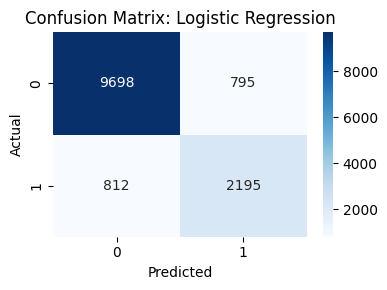


[Decision Tree]
Accuracy: 0.8973
Precision: 0.7643
F1-score: 0.7718
Confusion Matrix:
[[9770  723]
 [ 663 2344]]


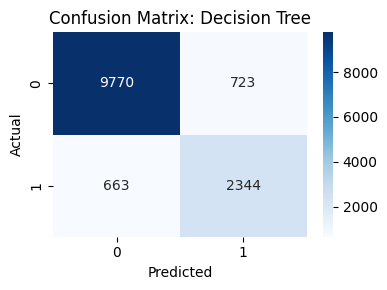


[Random Forest]
Accuracy: 0.9247
Precision: 0.8795
F1-score: 0.8195
Confusion Matrix:
[[10177   316]
 [  700  2307]]


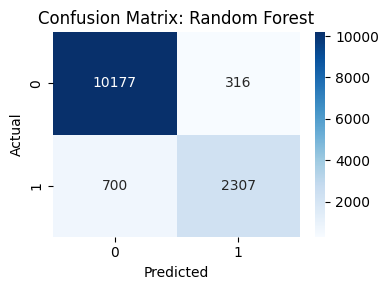

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix

# Load the dataset directly from your upload path
df = pd.read_csv('/kaggle/input/datasets/chideraihejirika/loan-approval-data/loan_approval_dataset.csv')

# Clean up column spaces so they map properly
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# --- TASK 1: INSPECT THE DATASET ---
print("--- TASK 1 REPORT ---")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Number of missing values: {df.isnull().sum().sum()}")

# --- TASK 2: PREPARE THE DATASET ---
if 'loan_id' in df.columns:
    df = df.drop('loan_id', axis=1)
df = df.dropna()

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
print("\n--- TASK 2 COMPLETED ---")

# --- TASK 3: BUILD CLASSIFICATION MODELS ---
# Separate features (X) and target label (y)
X = df.drop('Loan Status', axis=1)
y = df['Loan Status']

# Split dataset into Train (70%) and Test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the 3 required assignment models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# ==========================================
# TASK 4: EVALUATE THE MODEL AND REPORT
# ==========================================
print("\n--- TASK 4 EVALUATION REPORT ---")
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    # Predict on the test data
    y_pred = model.predict(X_test)
    
    # Calculate required assignment metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Display the results exactly as requested
    print(f"\n[{name}]")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Generate and save the visualization chart requested for your doc
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{name.lower().replace(" ", "_")}_cm.png')
    plt.show()